In [34]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')

import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre

from pathlib import Path

# 重新导入模块以确保使用最新版本（如果修改了 utils_clean.py）
import importlib
import utils_clean
importlib.reload(utils_clean)
from utils_clean import (
    prepare_training_data,
    evaluate_autosort_model,
    match_neurons,
    calibration_model,
    real_time_processing,
    generate_confusion_matrix_df,
    compute_noise_detection_metrics,
    SimpleAutoSort,
    SimpleWaveformLoader
)


In [2]:
# 加载数据
recording_path = '/media/ubuntu/sda/data/mouse6/ns4/natural_image/mouse6_031722_natural_image_001.ns4'
spike_inf_path = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/031722/spike_inf.tsv"
neuron_inf_path = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/031722/neuron_inf.pkl"

# 加载 GT 数据
spike_inf = pd.read_csv(spike_inf_path, sep='\t', index_col=0)
with open(neuron_inf_path, 'rb') as f:
    neuron_inf = pickle.load(f)

# 加载并预处理 recording
recording_raw = se.read_blackrock(file_path=recording_path)
recording_recorded = recording_raw.remove_channels(["98", '31', '32'])
recording_f = spre.bandpass_filter(recording_recorded, freq_min=300, freq_max=3000)
recording_f = spre.common_reference(recording_f, reference="global", operator="median")

print(f"Recording 加载完成")
print(f"采样率: {recording_f.get_sampling_frequency()} Hz")
print(f"通道数: {recording_f.get_num_channels()}")


Recording 加载完成
采样率: 10000.0 Hz
通道数: 30


## 步骤 1: 准备评估数据

可以选择：
- **选项A**: 使用已有的训练数据（如果已经运行过训练流程）
- **选项B**: 重新准备数据（如果需要评估新的数据）


In [3]:
# 设置路径
save_dir = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/"
eval_data_dir = Path(save_dir) / "eval_data"  # 评估数据目录

# 选项A: 使用已有数据（如果数据已存在）
use_existing_data = False  # 设置为 False 以重新准备数据

if use_existing_data and (eval_data_dir / "train_data").exists():
    eval_train_data_dir = eval_data_dir / "train_data"
    print(f"使用已有评估数据: {eval_train_data_dir}")
    print("如果数据不存在或需要重新准备，请设置 use_existing_data = False")
else:
    # 选项B: 重新准备数据
    print("重新准备评估数据...")
    duration_seconds = 200  # 处理时长（秒）
    
    # 检测参数（与训练时保持一致）
    detection_params = {
        'thr_min': 3.5,
        'thr_max': 30,
        'distance': 3,
        'ch_max_simul_firing': 5,
        'wlen': 5,
        'prominence': 10,
    }
    
    # 波形窗口参数
    window_params = {
        'left_sample': 10,
        'right_sample': 20,
    }
    
    # 准备数据（保存到 eval_data 目录）
    eval_train_data_dir = prepare_training_data(
        recording_f=recording_f,
        spike_inf=spike_inf,
        neuron_inf=neuron_inf,
        save_dir=str(eval_data_dir) + "/",  # 保存到 eval_data 目录
        duration_seconds=duration_seconds,
        **detection_params,
        **window_params
    )

# 设置评估时使用的数据目录
train_data_dir = eval_train_data_dir


重新准备评估数据...
### 1. 阈值检测
采样率: 10000.0 Hz, 通道数: 30
Recording总长度: 26000100 采样点 (2600.01 秒)
将处理前 2000000 采样点 (200.00 秒)
数据形状: (2000000, 30)
构建 detect_array...
检测到的 spike 数量: 448257

### 2. 加载 Ground Truth 并匹配
构建 gt_array...
GT spike 数量: 90556
---spike detection rate: 0.9469
匹配到的 spike 数量: 85745
未匹配的 spike 数量: 362512

### 3. 提取波形


提取波形: 100%|██████████| 30/30 [00:09<00:00,  3.24it/s]


波形提取完成！
waveform 形状: (448248, 30, 30)

### 4. 保存训练数据
保存目录: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/eval_data/train_data
  ✓ neuron_mapping.pkl 已保存
保存数据...
  ✓ X_waveform.pkl 已保存
  ✓ Y_spike_id.pkl 已保存
  ✓ Y_spike_id_noise.pkl 已保存
  ✓ X_spiketrain_time.pkl 已保存

所有数据已保存到: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/eval_data/train_data
数据统计:
  - 总 spike 数量: 448248
  - 通道数: 30
  - 窗口长度: 30
  - 唯一单元数: 28
  - 噪声 spike 数量: 362504
  - 有效 spike 数量: 85744


## 步骤 2: 加载模型并评估


In [8]:
# 加载训练数据的 neuron_inf
train_neuron_inf_path = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/021322/neuron_inf.pkl"
with open(train_neuron_inf_path, 'rb') as f:
    train_neuron_inf = pickle.load(f)

# 进行 neuron 匹配
# 注意：函数直接使用 neuron_inf 中的 position_1, position_2 和 position_waveform 列
# 不再需要加载波形数据文件，train_data_dir 和 eval_data_dir 参数已不再使用
eval_neuron_inf_matched = match_neurons(
    train_neuron_inf=train_neuron_inf,
    eval_neuron_inf=neuron_inf,
    position_threshold=10,  # 位置距离阈值（欧氏距离，单位：微米）
    waveform_similarity_threshold=0.95  # 波形相似性阈值（Pearson相关系数）
)



Neuron 匹配
进行 neuron 匹配...
  Neuron_6 -> Neuron_1 (相似性: 0.9864, 位置距离: 7.60)
  Neuron_16 -> Neuron_22 (相似性: 0.9958, 位置距离: 2.83)
  Neuron_17 -> Neuron_20 (相似性: 0.9567, 位置距离: 5.57)
  Neuron_19 -> Neuron_17 (相似性: 0.9922, 位置距离: 5.97)
  Neuron_22 -> Neuron_28 (相似性: 0.9887, 位置距离: 3.27)
  Neuron_24 -> Neuron_34 (相似性: 0.9770, 位置距离: 9.25)
  Neuron_26 -> Neuron_34 (相似性: 0.9959, 位置距离: 8.80)
  Neuron_28 -> Neuron_31 (相似性: 0.9970, 位置距离: 4.19)
  Neuron_32 -> Neuron_30 (相似性: 0.9975, 位置距离: 8.38)
  Neuron_36 -> Neuron_42 (相似性: 0.9977, 位置距离: 3.43)
  Neuron_37 -> Neuron_45 (相似性: 0.9912, 位置距离: 7.11)
  Neuron_43 -> Neuron_45 (相似性: 0.9548, 位置距离: 6.14)
  Neuron_45 -> Neuron_51 (相似性: 0.9918, 位置距离: 3.49)
  Neuron_47 -> Neuron_53 (相似性: 0.9712, 位置距离: 3.41)
  Neuron_52 -> Neuron_57 (相似性: 0.9867, 位置距离: 5.86)
  Neuron_53 -> Neuron_55 (相似性: 0.9958, 位置距离: 3.93)
  Neuron_55 -> Neuron_69 (相似性: 0.9902, 位置距离: 8.78)
  Neuron_57 -> Neuron_70 (相似性: 0.9982, 位置距离: 6.14)

匹配完成:
  - 总评估 neuron 数: 28
  - 匹配成功: 18
  - 未匹配: 10


## 步骤 3: 加载模型并评估


In [9]:
# 设置评估参数
model_save_dir = save_dir + "model_save/"
n_channels = recording_f.get_num_channels()

evaluation_params = {
    'batch_size': 512,
    'left_sample': 10,
    'right_sample': 20,
}

# 评估模型（传入匹配后的 neuron_inf，计算两套结果）
results = evaluate_autosort_model(
    train_data_dir=train_data_dir,  # 评估数据目录
    model_save_dir=model_save_dir,
    n_channels=n_channels,
    **evaluation_params,
    save_results=True,
    eval_neuron_inf_matched=eval_neuron_inf_matched,  # 传入匹配后的 neuron_inf
    eval_data_dir=train_data_dir  # 评估数据目录（用于加载 neuron_mapping）
)

print("\n评估完成！")


使用设备: cuda
从文件加载训练时的单元ID列表: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/model_save/keep_id.pkl
训练时的单元数量: 27
创建 dataset...
Dataset 加载完成:
  - 总样本数: 448248
  - 通道数: 30
  - 窗口长度: 30
  - 唯一单元数: 27
  - 噪声样本数: 362765.0
  - 非噪声样本数: 85483.0
模型参数:
  - 通道数: 30
  - 窗口长度: 30
  - 单元数量: 27
  - 使用训练时的单元ID列表: True
加载模型权重...
模型加载完成

开始评估（共 448248 样本）...


评估: 100%|██████████| 876/876 [00:03<00:00, 227.27it/s]



评估结果（原始）:
  - 噪声分类准确率: 0.8408
  - 单元分类准确率: 0.2553
  - 单元分类F1分数: 0.2553
  - 评估的单元样本数: 85483
  - 总样本数: 448248

计算调整后的评估结果（将 unmatch neuron 视为 noise）...
  - 未匹配的 neuron 数量: 10
  - 未匹配的 neuron: ['Neuron_4' 'Neuron_9' 'Neuron_10' 'Neuron_11' 'Neuron_12' 'Neuron_21'
 'Neuron_27' 'Neuron_29' 'Neuron_42' 'Neuron_49']
  - 调整的样本数: 14202

评估结果（调整后）:
  - 噪声分类准确率: 0.8464
  - 总样本数: 448248
  - 单元分类准确率: 0.3190
  - 单元分类F1分数: 0.2653
  - 评估的单元样本数: 85483
    - 其中匹配的neuron样本: 71281
    - 其中未匹配的neuron样本: 14202
      - 正确识别为噪声: 8364 (58.9%)
      - 误判为单元: 5838 (41.1%)
    - 说明: 未匹配的neuron样本被视为噪声，如果网络正确识别为噪声则计入正确，如果误判为单元则计入错误

评估结果已保存到: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/model_save/evaluation_results.csv
评估摘要已保存到: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/model_save/evaluation_summary.csv

评估完成！


## 步骤 4: 优化的分类流程（两阶段方法）

使用新的两阶段方法：
- **第一阶段（Calibration）**: 前60s数据，提取way3特征，PCA降维，K-means聚类，与train neuron匹配
- **第二阶段（实时处理）**: 按time_window处理，使用第一阶段建立的模型和映射关系


In [11]:
# 加载训练数据的 neuron_inf（用于calibration匹配）
train_neuron_inf_path = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/021322/neuron_inf.pkl"
with open(train_neuron_inf_path, 'rb') as f:
    train_neuron_inf = pickle.load(f)

print(f"训练数据的neuron数量: {len(train_neuron_inf)}")
print(f"训练数据的neuron列表: {train_neuron_inf['Neuron'].tolist()}")


训练数据的neuron数量: 27
训练数据的neuron列表: ['Neuron_1', 'Neuron_2', 'Neuron_4', 'Neuron_11', 'Neuron_17', 'Neuron_20', 'Neuron_22', 'Neuron_24', 'Neuron_25', 'Neuron_27', 'Neuron_28', 'Neuron_30', 'Neuron_31', 'Neuron_34', 'Neuron_40', 'Neuron_42', 'Neuron_43', 'Neuron_45', 'Neuron_48', 'Neuron_51', 'Neuron_52', 'Neuron_53', 'Neuron_54', 'Neuron_55', 'Neuron_57', 'Neuron_69', 'Neuron_70']


In [14]:
# 加载模型
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 创建模型（需要先加载dataset以获取keep_id和权重）
model_save_dir = save_dir + "model_save/"
n_channels = recording_f.get_num_channels()

# 加载keep_id
with open(model_save_dir + 'keep_id.pkl', 'rb') as f:
    keep_id = pickle.load(f)

# 创建dataset以获取权重（用于模型初始化，但评估时不会使用）
dataset = SimpleWaveformLoader(
    root=str(train_data_dir) + '/',
    shank_channel=np.arange(n_channels),
    Keep_id=keep_id
)

# 创建模型
autosort_model = SimpleAutoSort(
    ch_num=n_channels,
    samplepoints=30,  # left_sample + right_sample
    device=device,
    set_shank_id=keep_id,
    save_dir=model_save_dir,
    pos_weight_noise=dataset.pos_weight_noise.to(device),
    pos_weight_label=dataset.pos_weight_label.to(device)
)

# 加载模型权重
autosort_model.load_model()
autosort_model.eval()
print("模型加载完成")


使用设备: cuda
Dataset 加载完成:
  - 总样本数: 448248
  - 通道数: 30
  - 窗口长度: 30
  - 唯一单元数: 27
  - 噪声样本数: 362765.0
  - 非噪声样本数: 85483.0
模型加载完成


In [29]:
# 第一阶段：Calibration（前60秒）
calibration_duration_seconds = 60
n_additional_clusters = 10  # 额外的cluster数量

detection_params = {
    'thr_min': 3.5,
    'thr_max': 30,
    'distance': 3,
    'ch_max_simul_firing': 5,
    'wlen': 5,
    'prominence': 10,
}

window_params = {
    'left_sample': 10,
    'right_sample': 20,
}

calibration_results = calibration_model(
    recording_f=recording_f,
    autosort_model=autosort_model,
    train_neuron_inf=train_neuron_inf,
    calibration_duration_seconds=calibration_duration_seconds,
    n_additional_clusters=n_additional_clusters,
    detection_params=detection_params,
    window_params=window_params,
    position_threshold=10.0,
    waveform_similarity_threshold=0.9,
    eval_neuron_inf=eval_neuron_inf_matched,  # 使用匹配后的neuron_inf
    eval_spike_inf=spike_inf,  # 使用spike_inf
    device=device,
)

print("\nCalibration完成！")
print(f"  - K-means模型: {calibration_results['kmeans_model']}")
print(f"  - PCA模型: {calibration_results['pca_model']}")
print(f"  - Cluster到Neuron映射: {len(calibration_results['cluster_to_neuron_mapping'])} 个")
print(f"  - Neuron到Clusters映射: {len(calibration_results['neuron_to_clusters'])} 个")


第一阶段：Calibration (前60秒)
加载前 60 秒的数据...
数据形状: (30, 600000)

### 2. 阈值检测
检测到的spike数量: 133412

### 3. 提取波形
有效spike数量: 133407

### 4. Noise分类器过滤


Noise分类: 100%|██████████| 261/261 [00:00<00:00, 792.26it/s]


通过noise分类器的spike数量: 37503

### 5. PCA降维
PCA降维后特征形状: (37503, 30)
PCA解释方差比: 0.9184

### 6. K-means聚类
聚类数: 37 (训练neuron数: 27, 额外: 10)
聚类完成，每个cluster的样本数:
  Cluster 0: 298 样本
  Cluster 1: 1126 样本
  Cluster 2: 1603 样本
  Cluster 3: 1762 样本
  Cluster 4: 656 样本
  Cluster 5: 654 样本
  Cluster 6: 1210 样本
  Cluster 7: 1187 样本
  Cluster 8: 1139 样本
  Cluster 9: 908 样本
  Cluster 10: 1002 样本
  Cluster 11: 2847 样本
  Cluster 12: 2763 样本
  Cluster 13: 816 样本
  Cluster 14: 1171 样本
  Cluster 15: 404 样本
  Cluster 16: 892 样本
  Cluster 17: 1293 样本
  Cluster 18: 506 样本
  Cluster 19: 703 样本
  Cluster 20: 598 样本
  Cluster 21: 529 样本
  Cluster 22: 933 样本
  Cluster 23: 1059 样本
  Cluster 24: 1242 样本
  Cluster 25: 489 样本
  Cluster 26: 2723 样本
  Cluster 27: 1329 样本
  Cluster 28: 407 样本
  Cluster 29: 1350 样本
  Cluster 30: 665 样本
  Cluster 31: 410 样本
  Cluster 32: 223 样本
  Cluster 33: 586 样本
  Cluster 34: 1038 样本
  Cluster 35: 396 样本
  Cluster 36: 586 样本

### 7. 计算cluster位置和波形（基于train neuron的channel_id）并匹配

  处理 Neuron

Calibration阶段 Confusion Matrix
predicted_label  Neuron_1  Neuron_17  Neuron_20  Neuron_22  Neuron_25  \
gt_label                                                                
Neuron_1              667          8          0          4          3   
Neuron_17               0        255          3          0          1   
Neuron_20               1         54        231          1         14   
Neuron_22               0        271          2        718          3   
Neuron_25               0          0          0          0          0   
Neuron_27               0          0          0          0          0   
Neuron_28               0          1          2          3          3   
Neuron_30               8          2          1          1          6   
Neuron_31               3         16          5          4          7   
Neuron_34               4         14          6          5         15   
Neuron_40               0          0          0          0          0   
Neuron_42           

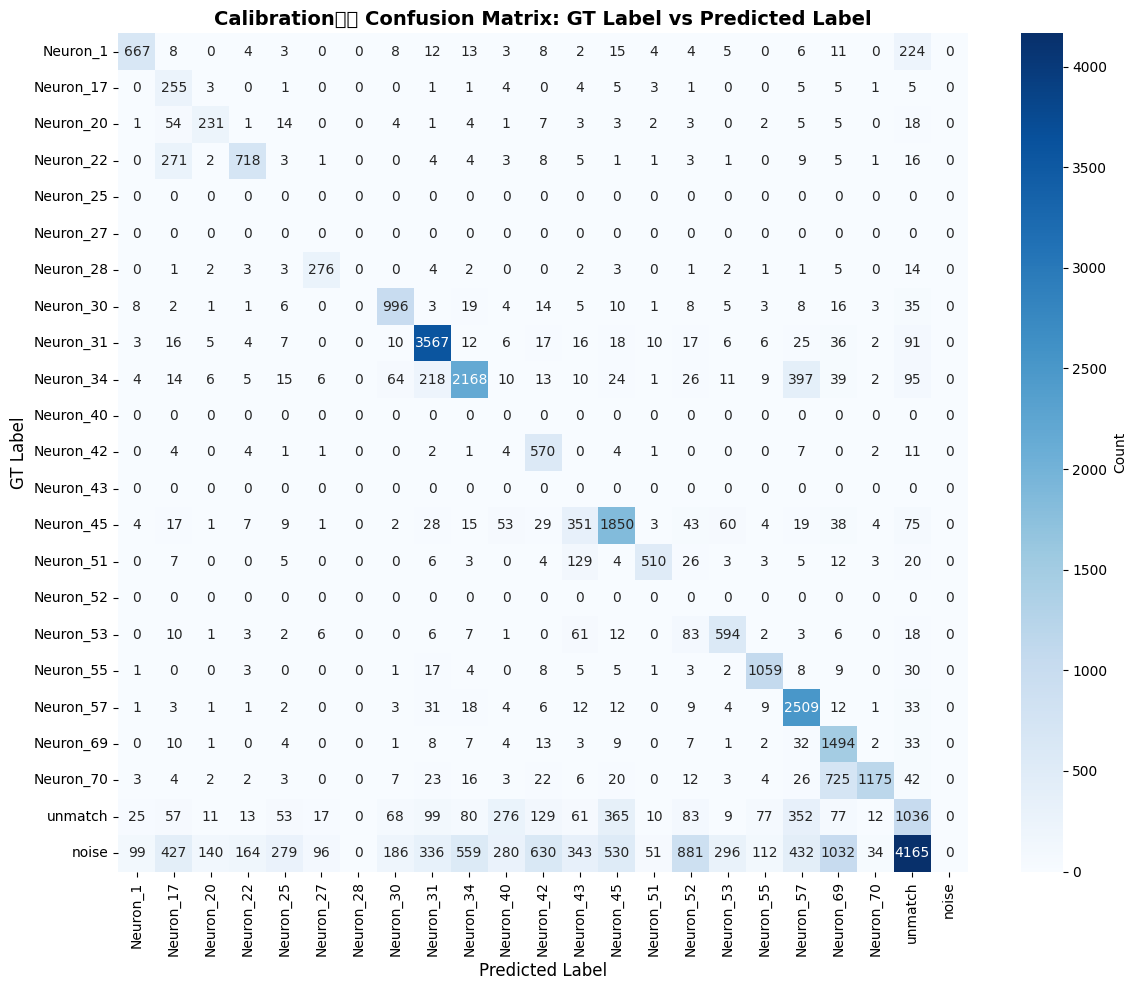


匹配neuron的准确率: 0.8068 (80.68%)
  - 匹配的样本数: 22761

Noise分类准确率: 0.3762 (37.62%)
  - Noise样本数: 11072
  - 正确识别为unmatch: 4165
  - 误判为neuron: 6907

Calibration阶段 Noise Detection 指标（重新计算）
说明：GT=noise且predicted=unmatch的，认为是真阴性（TN）

Noise Detection 混淆矩阵:
pred_noise  noise  spike    All
gt_noise                       
noise        4165   6907  11072
spike        1796  24635  26431
All          5961  31542  37503

Noise Detection 指标:
  - 真阳性 (TP): 24635
  - 真阴性 (TN): 4165
  - 假阳性 (FP): 6907
  - 假阴性 (FN): 1796
  - 总样本数: 37503

  - 准确率 (Accuracy): 0.7679 (76.79%)
  - 精确率 (Precision): 0.7810 (78.10%)
  - 召回率 (Recall): 0.9320 (93.20%)
  - F1分数: 0.8499
  - 特异性 (Specificity): 0.3762 (37.62%)


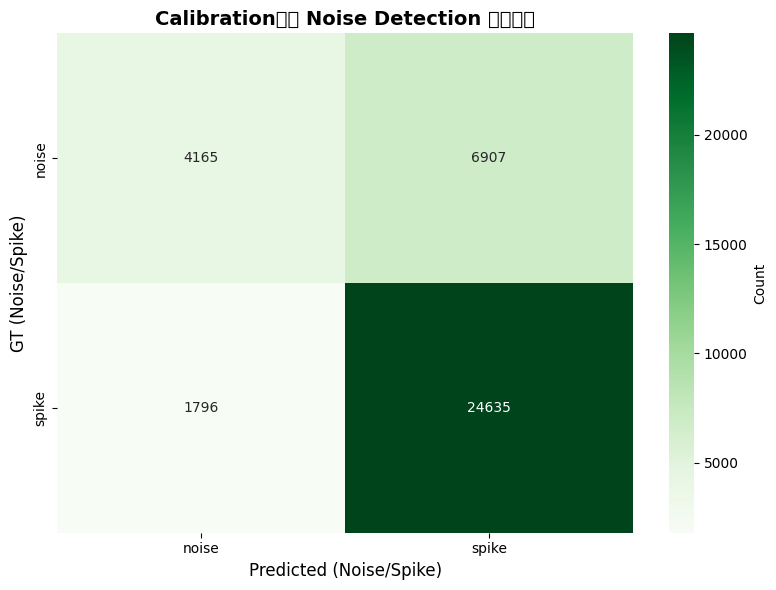

In [ ]:
# Calibration阶段的Confusion Matrix验证
if calibration_results['results_df'] is not None and 'gt_label' in calibration_results['results_df'].columns:
    calib_results_df = calibration_results['results_df']
    
    # 获取train neuron列表（用于排序）
    train_neuron_list = train_neuron_inf['Neuron'].tolist()
    
    # 生成confusion matrix
    calib_confusion_matrix, calib_summary_df = generate_confusion_matrix_df(
        results_df=calib_results_df,
        train_neuron_list=train_neuron_list
    )
    
    print("=" * 50)
    print("Calibration阶段 Confusion Matrix")
    print("=" * 50)
    print(calib_confusion_matrix)
    
    print(f"\n详细结果:")
    print(f"  - 总行数（经过noise classifier的spike数）: {len(calib_summary_df)}")
    print(f"  - GT标签分布:")
    print(calib_summary_df['gt_label'].value_counts().sort_index())
    print(f"  - 预测标签分布:")
    print(calib_summary_df['predicted_label'].value_counts().sort_index())
    
    # 绘制Confusion Matrix热力图
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 移除All行和列（如果存在）用于绘图
    calib_confusion_matrix_plot = calib_confusion_matrix.copy()
    if 'All' in calib_confusion_matrix_plot.index:
        calib_confusion_matrix_plot = calib_confusion_matrix_plot.drop('All')
    if 'All' in calib_confusion_matrix_plot.columns:
        calib_confusion_matrix_plot = calib_confusion_matrix_plot.drop('All', axis=1)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        calib_confusion_matrix_plot, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        cbar_kws={'label': 'Count'}
    )
    plt.title('Calibration阶段 Confusion Matrix: GT Label vs Predicted Label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('GT Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # 计算准确率
    if 'gt_label' in calib_summary_df.columns and 'predicted_label' in calib_summary_df.columns:
        # 只计算匹配的neuron（排除unmatch和noise）
        matched_df = calib_summary_df[
            (calib_summary_df['gt_label'] != 'unmatch') & 
            (calib_summary_df['gt_label'] != 'noise') &
            (calib_summary_df['predicted_label'] != 'unmatch')
        ]
        
        if len(matched_df) > 0:
            accuracy = (matched_df['gt_label'] == matched_df['predicted_label']).sum() / len(matched_df)
            print(f"\n匹配neuron的准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")
            print(f"  - 匹配的样本数: {len(matched_df)}")
        
        # 计算noise分类准确率
        noise_df = calib_summary_df[calib_summary_df['gt_label'] == 'noise']
        if len(noise_df) > 0:
            noise_accuracy = (noise_df['predicted_label'] == 'unmatch').sum() / len(noise_df)
            print(f"\nNoise分类准确率: {noise_accuracy:.4f} ({noise_accuracy*100:.2f}%)")
            print(f"  - Noise样本数: {len(noise_df)}")
            print(f"  - 正确识别为unmatch: {(noise_df['predicted_label'] == 'unmatch').sum()}")
            print(f"  - 误判为neuron: {(noise_df['predicted_label'] != 'unmatch').sum()}")
    
    # 重新计算Noise Detection的混淆矩阵和准确率
    print("\n" + "=" * 50)
    print("Calibration阶段 Noise Detection 指标（重新计算）")
    print("=" * 50)
    print("说明：GT=noise且predicted=unmatch的，认为是真阴性（TN）")
    
    noise_detection_metrics = compute_noise_detection_metrics(
        results_df=calib_results_df,
        train_neuron_list=train_neuron_list
    )
    
    print("\nNoise Detection 混淆矩阵:")
    print(noise_detection_metrics['confusion_matrix'])
    
    print(f"\nNoise Detection 指标:")
    print(f"  - 真阳性 (TP): {noise_detection_metrics['TP']}")
    print(f"  - 真阴性 (TN): {noise_detection_metrics['TN']}")
    print(f"  - 假阳性 (FP): {noise_detection_metrics['FP']}")
    print(f"  - 假阴性 (FN): {noise_detection_metrics['FN']}")
    print(f"  - 总样本数: {noise_detection_metrics['total_samples']}")
    print(f"\n  - 准确率 (Accuracy): {noise_detection_metrics['accuracy']:.4f} ({noise_detection_metrics['accuracy']*100:.2f}%)")
    print(f"  - 精确率 (Precision): {noise_detection_metrics['precision']:.4f} ({noise_detection_metrics['precision']*100:.2f}%)")
    print(f"  - 召回率 (Recall): {noise_detection_metrics['recall']:.4f} ({noise_detection_metrics['recall']*100:.2f}%)")
    print(f"  - F1分数: {noise_detection_metrics['f1_score']:.4f}")
    print(f"  - 特异性 (Specificity): {noise_detection_metrics['specificity']:.4f} ({noise_detection_metrics['specificity']*100:.2f}%)")
    
    # 绘制Noise Detection混淆矩阵热力图
    noise_cm_plot = noise_detection_metrics['confusion_matrix'].copy()
    if 'All' in noise_cm_plot.index:
        noise_cm_plot = noise_cm_plot.drop('All')
    if 'All' in noise_cm_plot.columns:
        noise_cm_plot = noise_cm_plot.drop('All', axis=1)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        noise_cm_plot, 
        annot=True, 
        fmt='d', 
        cmap='Greens',
        cbar_kws={'label': 'Count'}
    )
    plt.title('Calibration阶段 Noise Detection 混淆矩阵', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted (Noise/Spike)', fontsize=12)
    plt.ylabel('GT (Noise/Spike)', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("警告: Calibration阶段没有GT标签数据，无法生成Confusion Matrix")


In [ ]:
# 第二阶段：实时处理（从60秒开始，按time_window处理）
start_time_seconds = 60.0  # 从calibration之后开始
time_window_seconds = 10.0  # 每个时间窗口的长度（秒）
total_duration_seconds = None  # 总处理时长（秒），如果为None则处理到recording结束
# total_duration_seconds = 60.0  # 例如：只处理60秒的数据

# 传入eval_neuron_inf和eval_spike_inf以生成GT标签
processing_results = real_time_processing(
    recording_f=recording_f,
    autosort_model=autosort_model,
    calibration_results=calibration_results,
    start_time_seconds=start_time_seconds,
    time_window_seconds=time_window_seconds,
    total_duration_seconds=total_duration_seconds,  # 自定义总处理时长
    detection_params=detection_params,
    window_params=window_params,
    eval_neuron_inf=eval_neuron_inf_matched,  # 使用匹配后的neuron_inf
    eval_spike_inf=spike_inf,  # 使用spike_inf
    device=device,
)

print("\n实时处理完成！")
print(f"  - 总spike数: {len(processing_results['spike_predictions'])}")
print(f"  - 匹配的neuron数: {sum(1 for p in processing_results['spike_predictions'] if p != 'unmatch')}")
print(f"  - 未匹配数: {sum(1 for p in processing_results['spike_predictions'] if p == 'unmatch')}")

# 统计每个neuron的spike数量
from collections import Counter
neuron_counts = Counter(processing_results['spike_predictions'])
print(f"\n各neuron的spike数量:")
for neuron, count in sorted(neuron_counts.items()):
    print(f"  {neuron}: {count}")


KeyboardInterrupt: 

In [ ]:
# 生成Confusion Matrix
# 说明：得分计算公式为 score = corr / (1 + pos_distance / position_threshold)
# 其中 corr 是波形相关性（Pearson相关系数），pos_distance 是位置距离（微米），position_threshold 是阈值（默认10微米）
# 得分越高表示匹配越好（相关性越高、距离越小，得分越高）

results_df = processing_results['results_df']

# 获取train neuron列表（用于排序）
train_neuron_list = train_neuron_inf['Neuron'].tolist()

# 生成confusion matrix
confusion_matrix, summary_df = generate_confusion_matrix_df(
    results_df=results_df,
    train_neuron_list=train_neuron_list
)

print("Confusion Matrix:")
print(confusion_matrix)

print(f"\n详细结果DataFrame:")
print(f"  - 总行数（经过noise classifier的spike数）: {len(summary_df)}")
print(f"  - GT标签分布:")
print(summary_df['gt_label'].value_counts().sort_index())
print(f"  - 预测标签分布:")
print(summary_df['predicted_label'].value_counts().sort_index())

# 显示summary_df的前几行
print(f"\nSummary DataFrame (前10行):")
print(summary_df.head(10))


In [ ]:
# 绘制Confusion Matrix热力图
import matplotlib.pyplot as plt
import seaborn as sns

# 移除All行和列（如果存在）用于绘图
confusion_matrix_plot = confusion_matrix.copy()
if 'All' in confusion_matrix_plot.index:
    confusion_matrix_plot = confusion_matrix_plot.drop('All')
if 'All' in confusion_matrix_plot.columns:
    confusion_matrix_plot = confusion_matrix_plot.drop('All', axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(
    confusion_matrix_plot, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix: GT Label vs Predicted Label', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('GT Label', fontsize=12)
plt.tight_layout()
plt.show()

# 计算准确率
if 'gt_label' in summary_df.columns and 'predicted_label' in summary_df.columns:
    # 只计算匹配的neuron（排除unmatch和noise）
    matched_df = summary_df[
        (summary_df['gt_label'] != 'unmatch') & 
        (summary_df['gt_label'] != 'noise') &
        (summary_df['predicted_label'] != 'unmatch')
    ]
    
    if len(matched_df) > 0:
        accuracy = (matched_df['gt_label'] == matched_df['predicted_label']).sum() / len(matched_df)
        print(f"\n匹配neuron的准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"  - 匹配的样本数: {len(matched_df)}")
    
    # 计算noise分类准确率（GT为noise的样本，预测也应该是noise或unmatch）
    noise_df = summary_df[summary_df['gt_label'] == 'noise']
    if len(noise_df) > 0:
        noise_accuracy = (noise_df['predicted_label'] == 'unmatch').sum() / len(noise_df)
        print(f"\nNoise分类准确率: {noise_accuracy:.4f} ({noise_accuracy*100:.2f}%)")
        print(f"  - Noise样本数: {len(noise_df)}")
        print(f"  - 正确识别为unmatch: {(noise_df['predicted_label'] == 'unmatch').sum()}")
        print(f"  - 误判为neuron: {(noise_df['predicted_label'] != 'unmatch').sum()}")
    
    # 重新计算Noise Detection的混淆矩阵和准确率
    print("\n" + "=" * 50)
    print("实时处理阶段 Noise Detection 指标（重新计算）")
    print("=" * 50)
    print("说明：GT=noise且predicted=unmatch的，认为是真阴性（TN）")
    
    noise_detection_metrics = compute_noise_detection_metrics(
        results_df=results_df,
        train_neuron_list=train_neuron_list
    )
    
    print("\nNoise Detection 混淆矩阵:")
    print(noise_detection_metrics['confusion_matrix'])
    
    print(f"\nNoise Detection 指标:")
    print(f"  - 真阳性 (TP): {noise_detection_metrics['TP']}")
    print(f"  - 真阴性 (TN): {noise_detection_metrics['TN']}")
    print(f"  - 假阳性 (FP): {noise_detection_metrics['FP']}")
    print(f"  - 假阴性 (FN): {noise_detection_metrics['FN']}")
    print(f"  - 总样本数: {noise_detection_metrics['total_samples']}")
    print(f"\n  - 准确率 (Accuracy): {noise_detection_metrics['accuracy']:.4f} ({noise_detection_metrics['accuracy']*100:.2f}%)")
    print(f"  - 精确率 (Precision): {noise_detection_metrics['precision']:.4f} ({noise_detection_metrics['precision']*100:.2f}%)")
    print(f"  - 召回率 (Recall): {noise_detection_metrics['recall']:.4f} ({noise_detection_metrics['recall']*100:.2f}%)")
    print(f"  - F1分数: {noise_detection_metrics['f1_score']:.4f}")
    print(f"  - 特异性 (Specificity): {noise_detection_metrics['specificity']:.4f} ({noise_detection_metrics['specificity']*100:.2f}%)")
    
    # 绘制Noise Detection混淆矩阵热力图
    noise_cm_plot = noise_detection_metrics['confusion_matrix'].copy()
    if 'All' in noise_cm_plot.index:
        noise_cm_plot = noise_cm_plot.drop('All')
    if 'All' in noise_cm_plot.columns:
        noise_cm_plot = noise_cm_plot.drop('All', axis=1)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        noise_cm_plot, 
        annot=True, 
        fmt='d', 
        cmap='Greens',
        cbar_kws={'label': 'Count'}
    )
    plt.title('实时处理阶段 Noise Detection 混淆矩阵', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted (Noise/Spike)', fontsize=12)
    plt.ylabel('GT (Noise/Spike)', fontsize=12)
    plt.tight_layout()
    plt.show()
